In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.utils import shuffle
features = pd.read_excel('高温合金数据集.xlsx')
label1 = np.array(features['UTS'])
label2 = np.array(features['TYS'])
label3 = np.array(features['Elong'])
features= features.drop('UTS', axis = 1)
features= features.drop('TYS', axis = 1)
features= features.drop('Elong', axis = 1)
features= features.drop('合金的牌号', axis = 1)
features
n_samples, n_features = features.shape
features = pd.get_dummies(features)
feature_list = list(features.columns)#获取列名
features = np.array(features)#获取影响因子
from sklearn.preprocessing import MinMaxScaler, StandardScaler
features = MinMaxScaler().fit_transform(features)#将进行归一化处理
from sklearn.model_selection import train_test_split
test_ratio = 0.2#按照五比一划分数据集合；4/5的数据用于训练集合，1/5的数据用于验证集合。
SEED = 26 ### the test/train data is checked on this seed, it has similiar distribution to the whole dataset
train_features3, test_features3, train_labels3, test_labels3 = train_test_split(features, label3,
                                                                            test_size = test_ratio,
                                                                            random_state = SEED)
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
def evaluate(true_labels, pred_labels):
    errors = abs(pred_labels - true_labels)
    MAE = mean_absolute_error(true_labels, pred_labels)
    mape = 100 * np.mean(errors / true_labels)
    r2 = r2_score(true_labels, pred_labels)
    RMSE = mean_squared_error(true_labels, pred_labels,squared=False)
    return mape, MAE, RMSE, r2,

/Users/macbookpro/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/macbookpro/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
import xgboost as xgb
Model1 = xgb.XGBRegressor(random_state = SEED, booster='gbtree' , n_estimators=50, max_depth =45, learning_rate=0.35, gamma=500)
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import LeaveOneOut
from numpy import absolute
from numpy import mean
from numpy import std
from sklearn.model_selection import cross_validate
from sklearn.metrics import mean_squared_error
cv = LeaveOneOut()
Model1.fit(train_features3, train_labels3)
from sklearn.model_selection import cross_val_predict
y_pred1 = cross_val_predict(Model1, features, label3, cv=cv)
model_accuracy1, model_MAE1, model_RMSE1, model_r21 = evaluate(label3, y_pred1)
final_output = pd.DataFrame()
final_output.loc[:,1] = [model_accuracy1, model_MAE1, model_RMSE1, model_r21]
final_output=pd.DataFrame(final_output)
final_output=final_output.T
final_output.columns = ['MAPE', 'MAE', 'RMSE', 'R2']
final_output.index = ['EL']
final_output.to_excel(r'_output_LOOCV_XGB_EL.xlsx', index = True)

/var/folders/sy/gl301n8s5pl2fptdx8bcns5h0000gn/T/ipykernel_8272/2370660718.py:21: UserWarning: Pandas requires version '3.0.5' or newer of 'xlsxwriter' (version '3.0.3' currently installed).
  final_output.to_excel(r'_output_LOOCV_XGB_EL.xlsx', index = True)


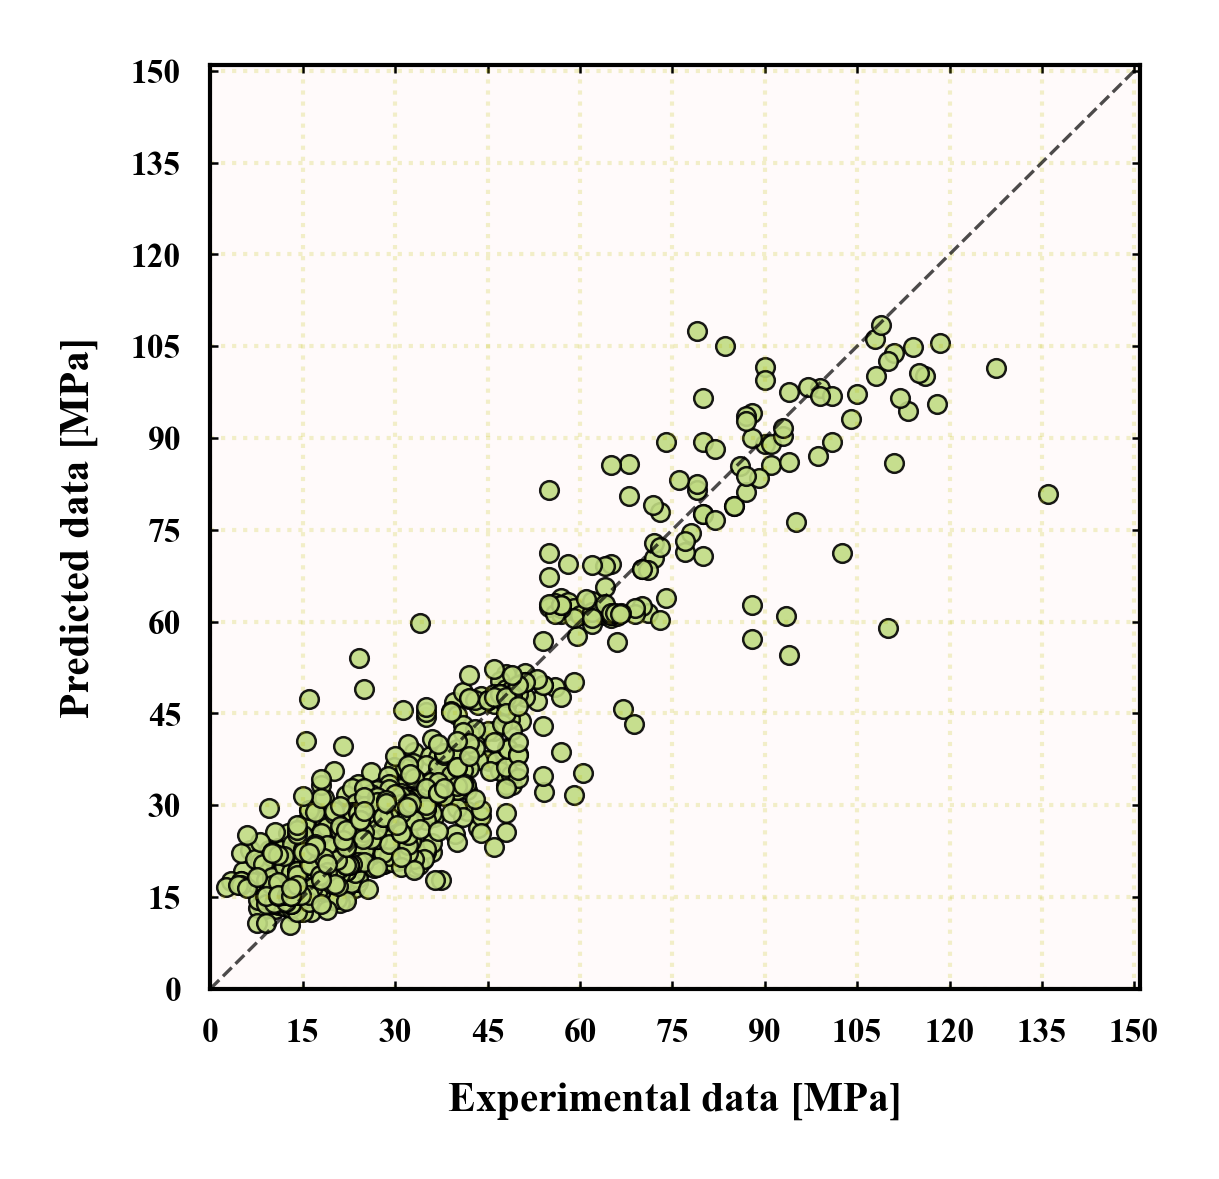

In [3]:
import matplotlib.pyplot as plt
predictions3 = y_pred1
test_labels3 = label3
########## UTS
plt.rcParams['figure.figsize']=(2.0,2.0)
plt.rcParams['savefig.dpi'] = 600 #图片像素
plt.rcParams['figure.dpi'] = 600 #分辨率
ax = plt.axes()
ax.set_facecolor("snow")
ax.set(facecolor = "snow")#背景颜色设置
plt.grid()
plt.tick_params(grid_color='y',grid_alpha=0.2,
                        grid_linewidth=0.5,grid_linestyle=':')#网格背景划分
ax.spines['bottom'].set_linewidth('0.5')#设置边框线宽为2.0
ax.spines['bottom'].set_linestyle("-")
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_linewidth('0.5')#设置边框线宽为2.0
ax.spines['left'].set_linestyle("-")
ax.spines['left'].set_color('black')
ax.spines['top'].set_linewidth('0.5')#设置边框线宽为2.0
ax.spines['top'].set_linestyle("-")
ax.spines['top'].set_color('black')
ax.spines['right'].set_linewidth('0.5')#设置边框线宽为2.0
ax.spines['right'].set_linestyle("-")
ax.spines['right'].set_color('black')
#设置图框线粗细
new_ticks = list(np.arange(0,151,15))
plt.xticks(new_ticks,size=4, weight='bold', fontname='Times New Roman')
plt.yticks(new_ticks,size=4, weight='bold', fontname='Times New Roman')
plt.tick_params( which='major', direction='in', length=1.0,width=0.3, color='red', top=True,right=True)#设置边框刻度
plt.plot([0,151],[0,151],'k--',linewidth = '0.4',alpha=0.7)
plt.scatter(test_labels3,predictions3,alpha=0.9,s=5,linewidths=0.3, c='#c0db82',edgecolor='#000000')
#plt.scatter(data_creep_time,y_cv_SVR,s=80,c='orange',edgecolor='k',alpha=0.7)
plt.tick_params(axis='x',colors='black')
plt.tick_params(axis='y',colors='black')
plt.xlabel('Experimental data [MPa]',size=5, weight='bold', fontname='Times New Roman')
plt.ylabel('Predicted data [MPa]',size=5, weight='bold', fontname='Times New Roman')
plt.margins(x=0)
plt.margins(y=0)
plt.show()